# Partial Coherence

This notebook explores how the focusing efficiency of optimized diffractive cascades depends on the spatial coherence properties of the illuminating X-ray beam. It sweeps over the coherence length ($\sigma_g$) and source size ($\sigma_s$) parameters of a Gaussian Schell-model beam and plots the resulting efficiency map.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

In [2]:
matplotlib.rcParams['figure.dpi'] = 200
matplotlib.rcParams.update({'font.size': 24})

In [3]:
from pathlib import Path

repo_root = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent

path = repo_root / "paper_data"

results = []
N_runs = 1
for i in range(N_runs):
    res = np.load(path / f"figA1_coherence_illumination_sweep_results_run_{i}.npz", allow_pickle=True)
    results.append(res)
params = np.load(path / "figA1_coherence_illumination_sweep_params.npy", allow_pickle=True).item()
sweep_arrs = np.load(path / "figA1_coherence_illumination_sweep_sweep_arrays.npy", allow_pickle=True).item()

In [4]:
sigma_g_arr = sweep_arrs['sigma_g']
sigma_s_arr = sweep_arrs['sigma_s']
opt_efficiencies = res['opt_efficiencies']

In [5]:
aperture_width = params['Nx'] * params['dx']

In [6]:
SG, SS = np.meshgrid(sigma_g_arr*1e6, sigma_s_arr*1e6)

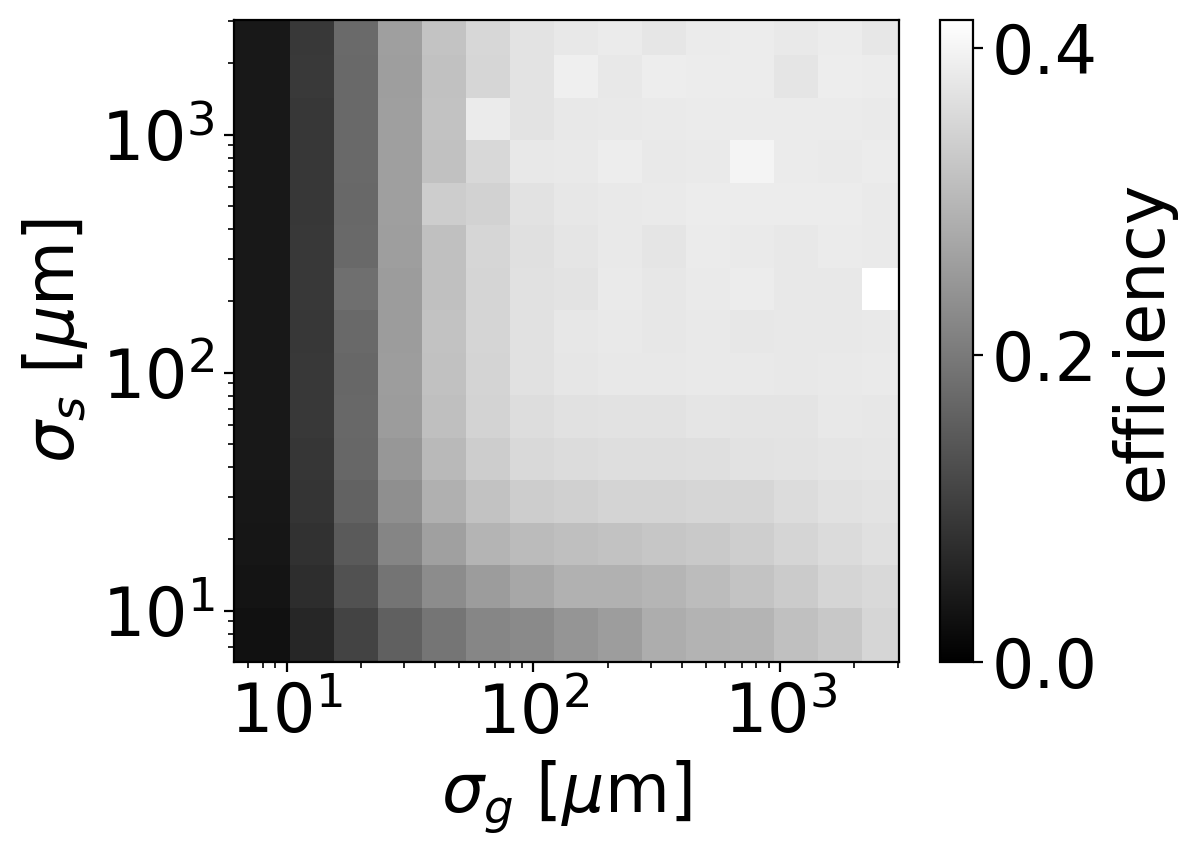

In [7]:
plt.pcolormesh(SG, SS, opt_efficiencies, cmap='gray', vmin=0.0, vmax=None)
plt.loglog()
plt.xlabel("$\\sigma_g$ [$\\mu$m]")
plt.ylabel("$\\sigma_s$ [$\\mu$m]")
plt.colorbar(label='efficiency')
plt.tight_layout()
plt.show()